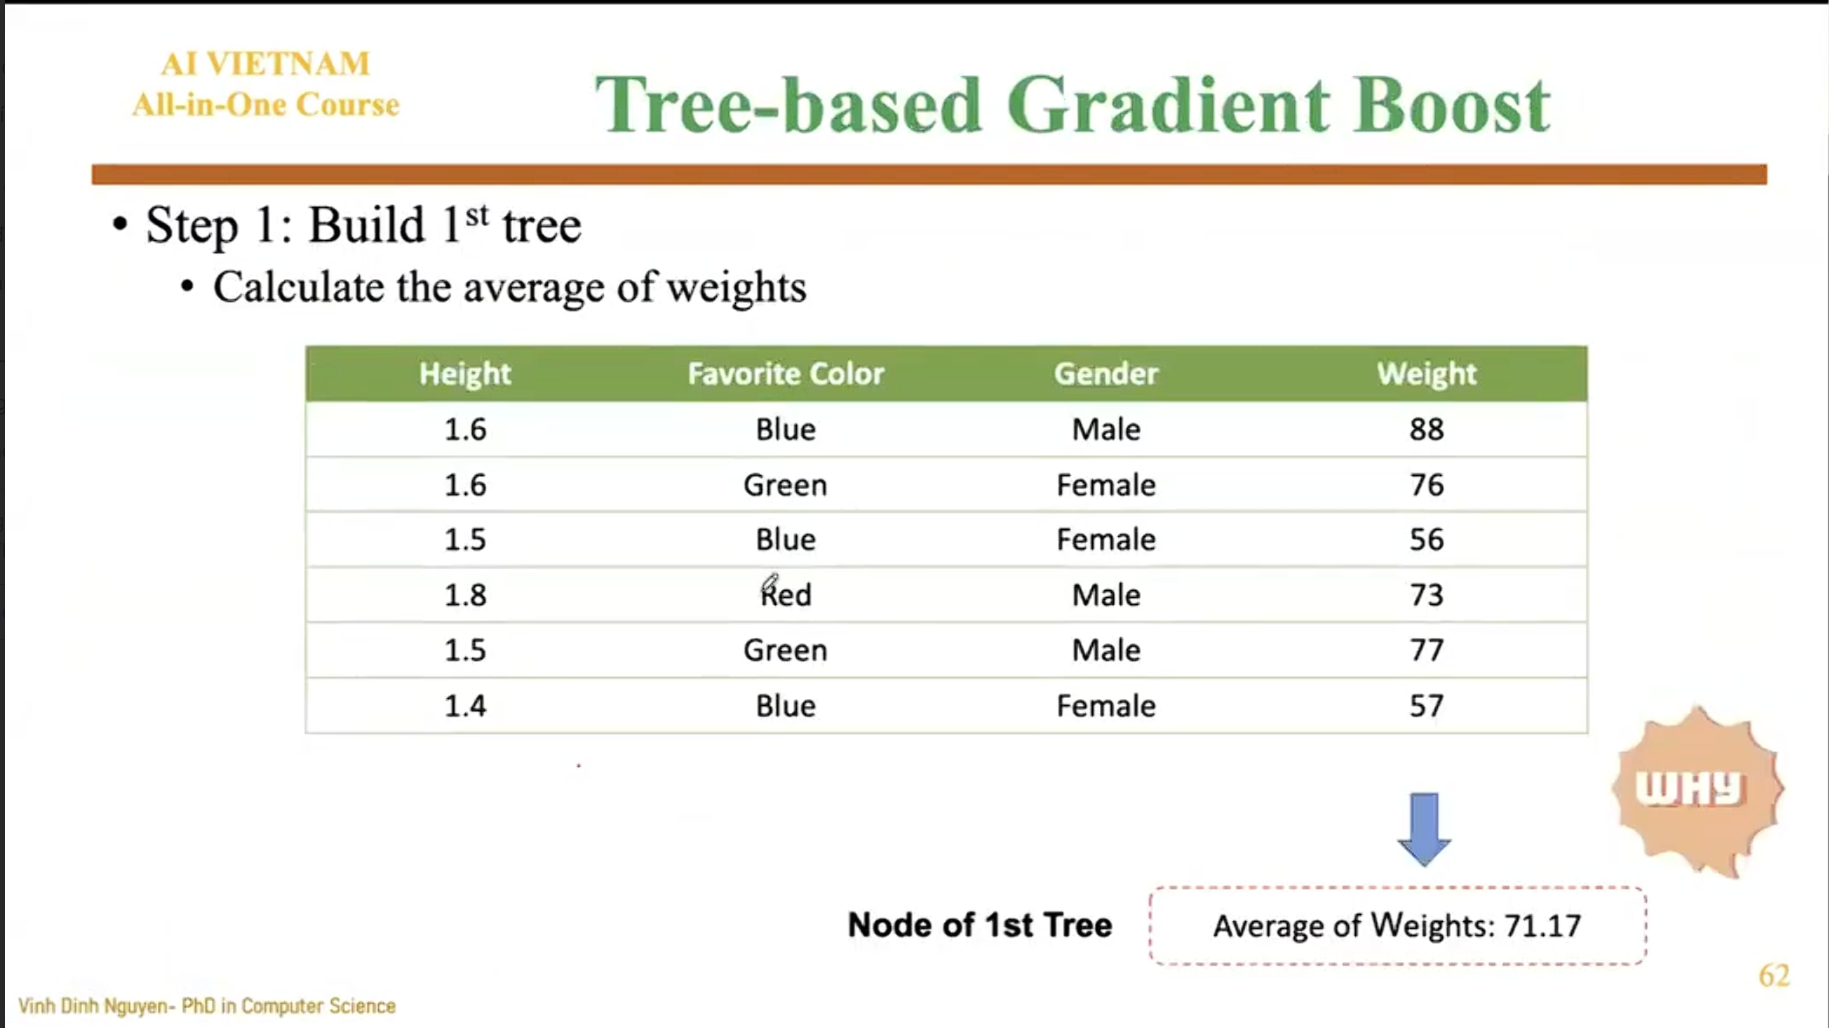

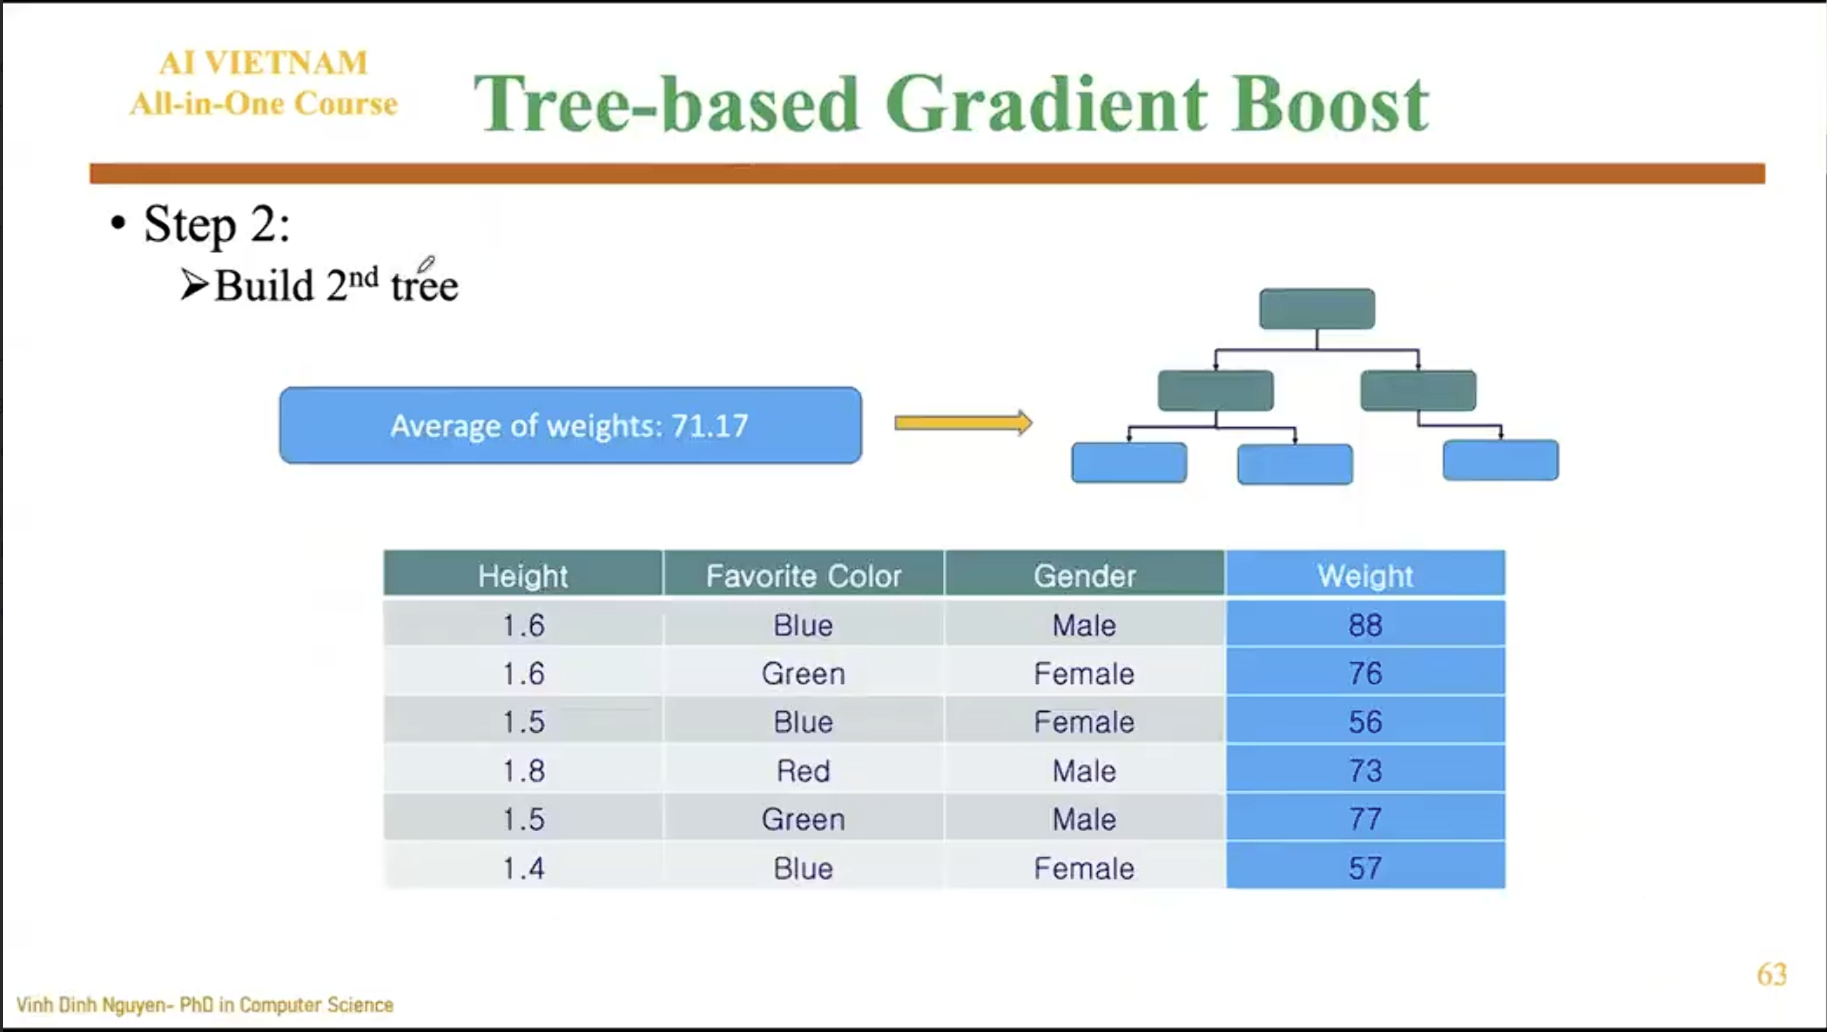

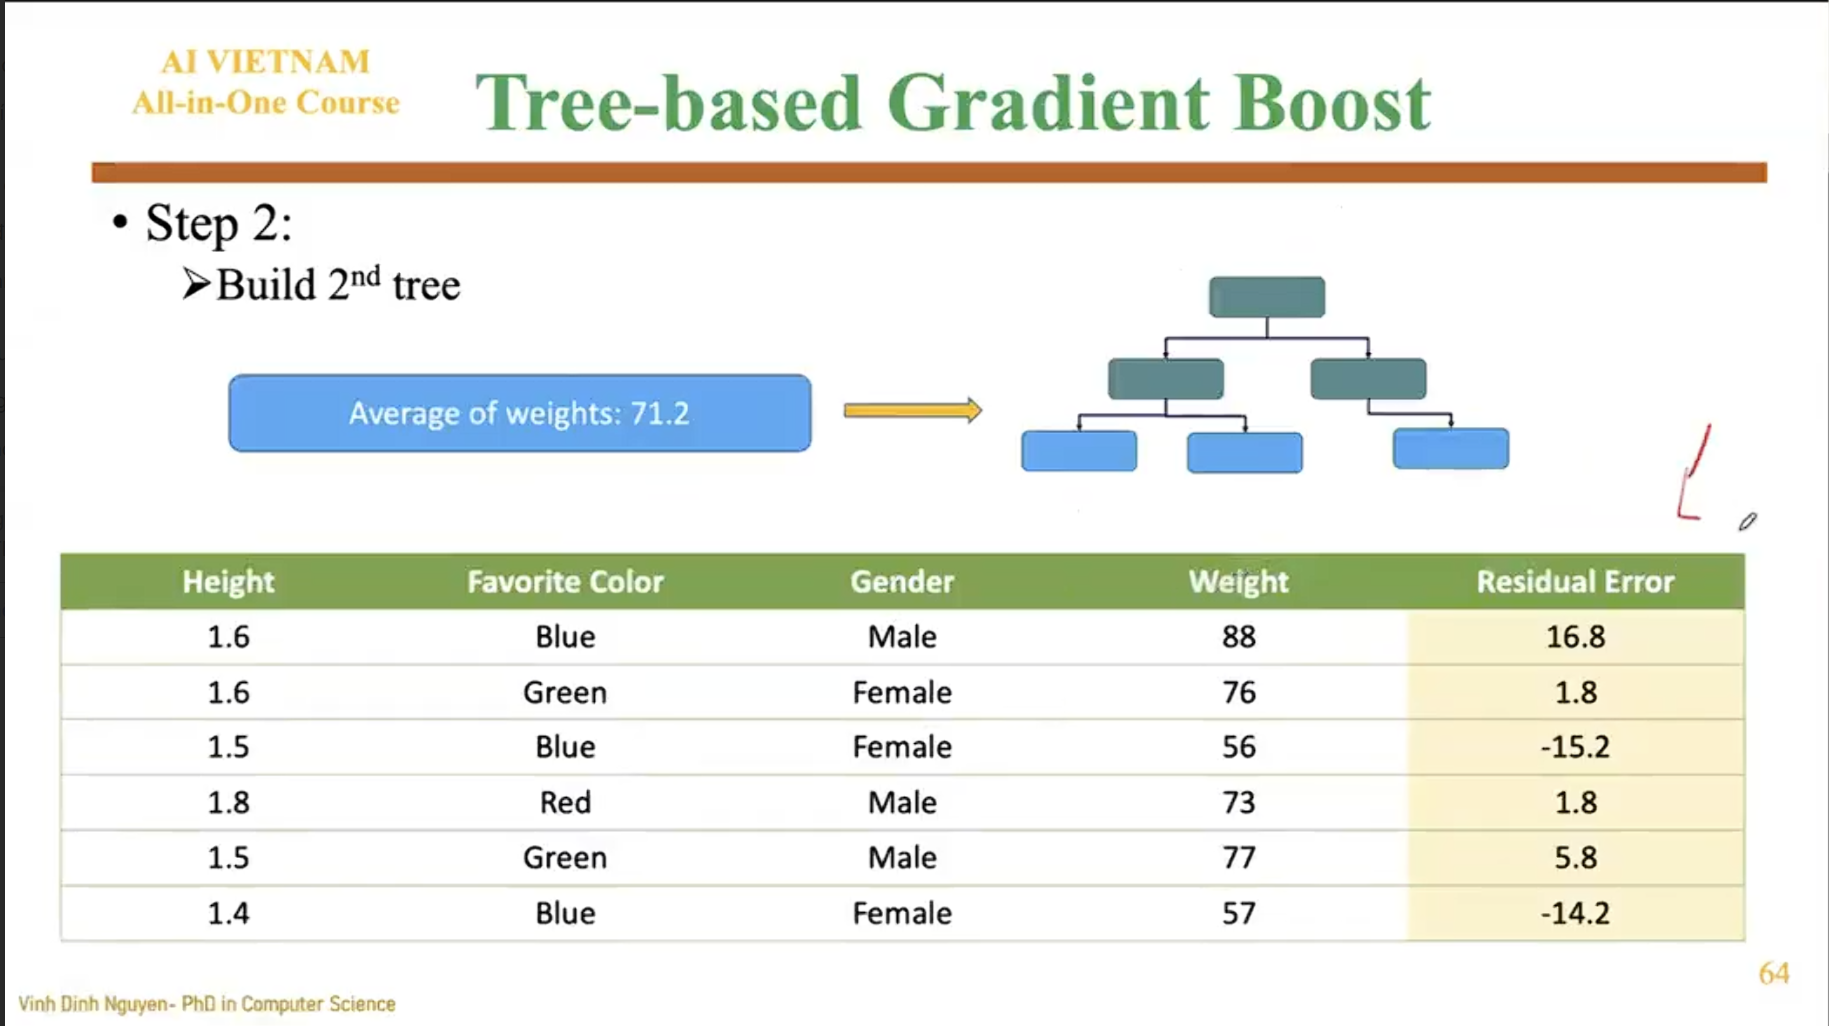

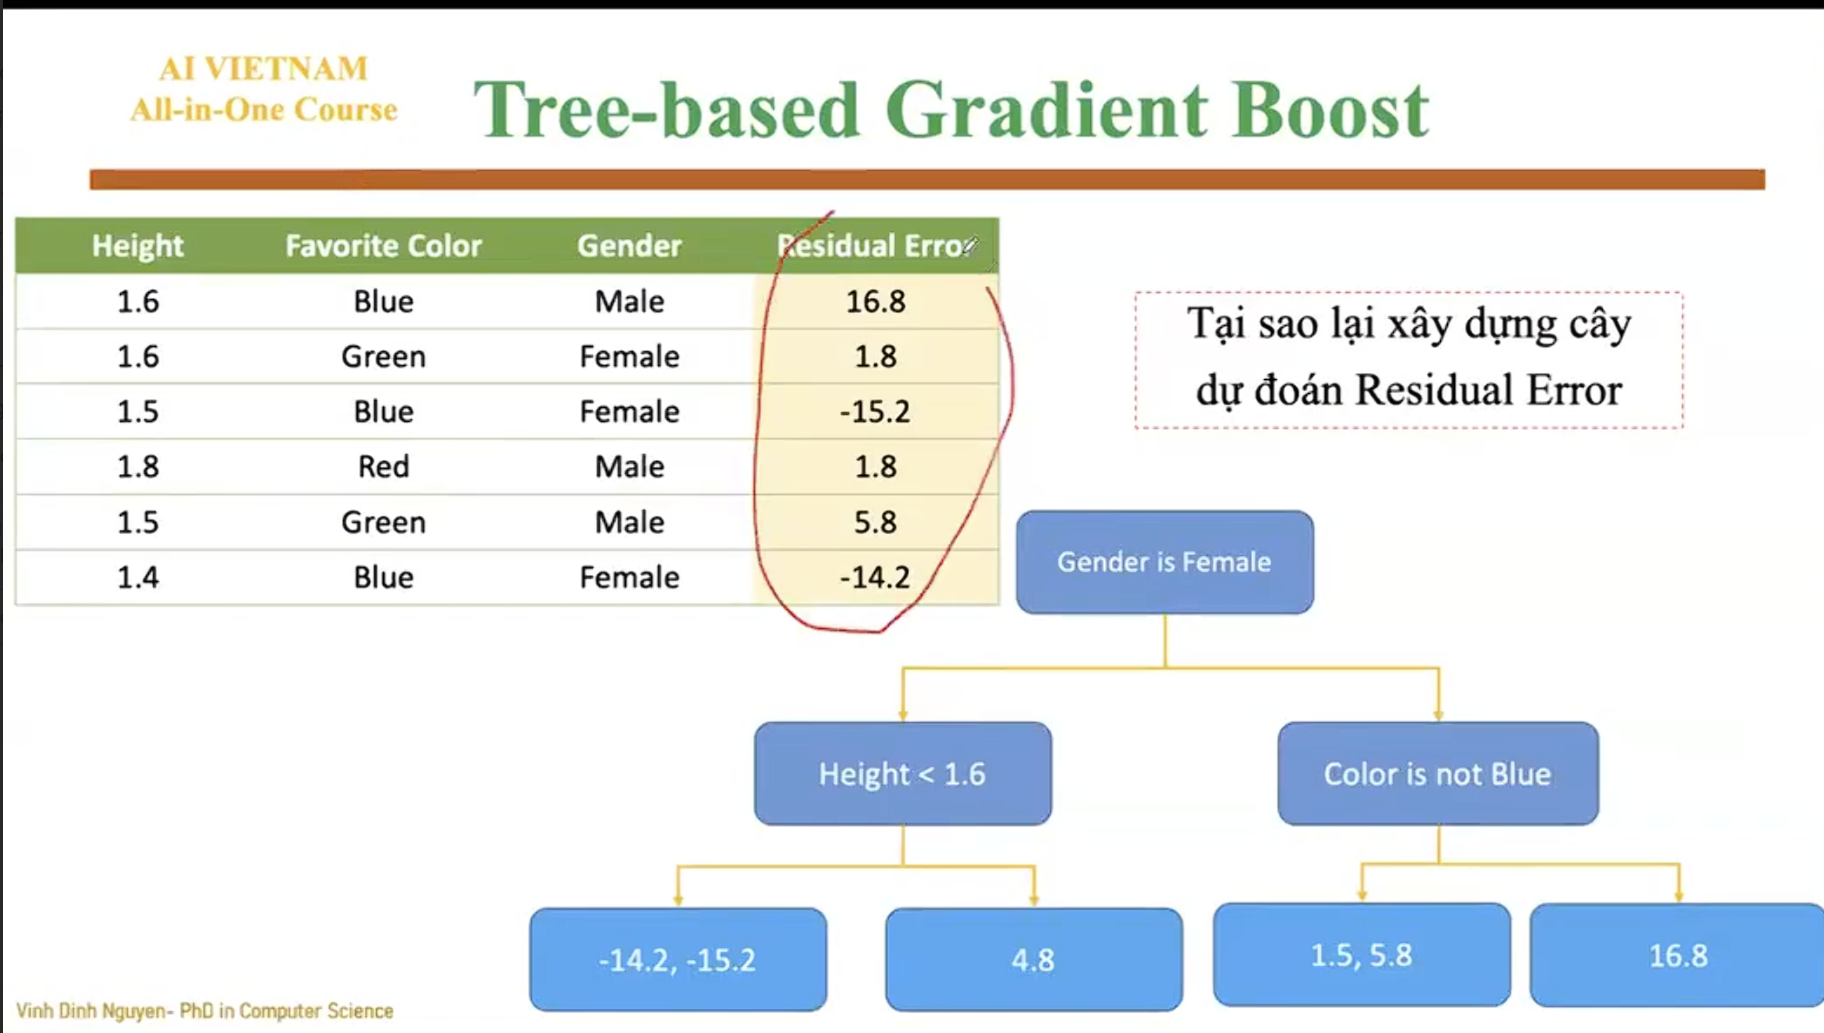

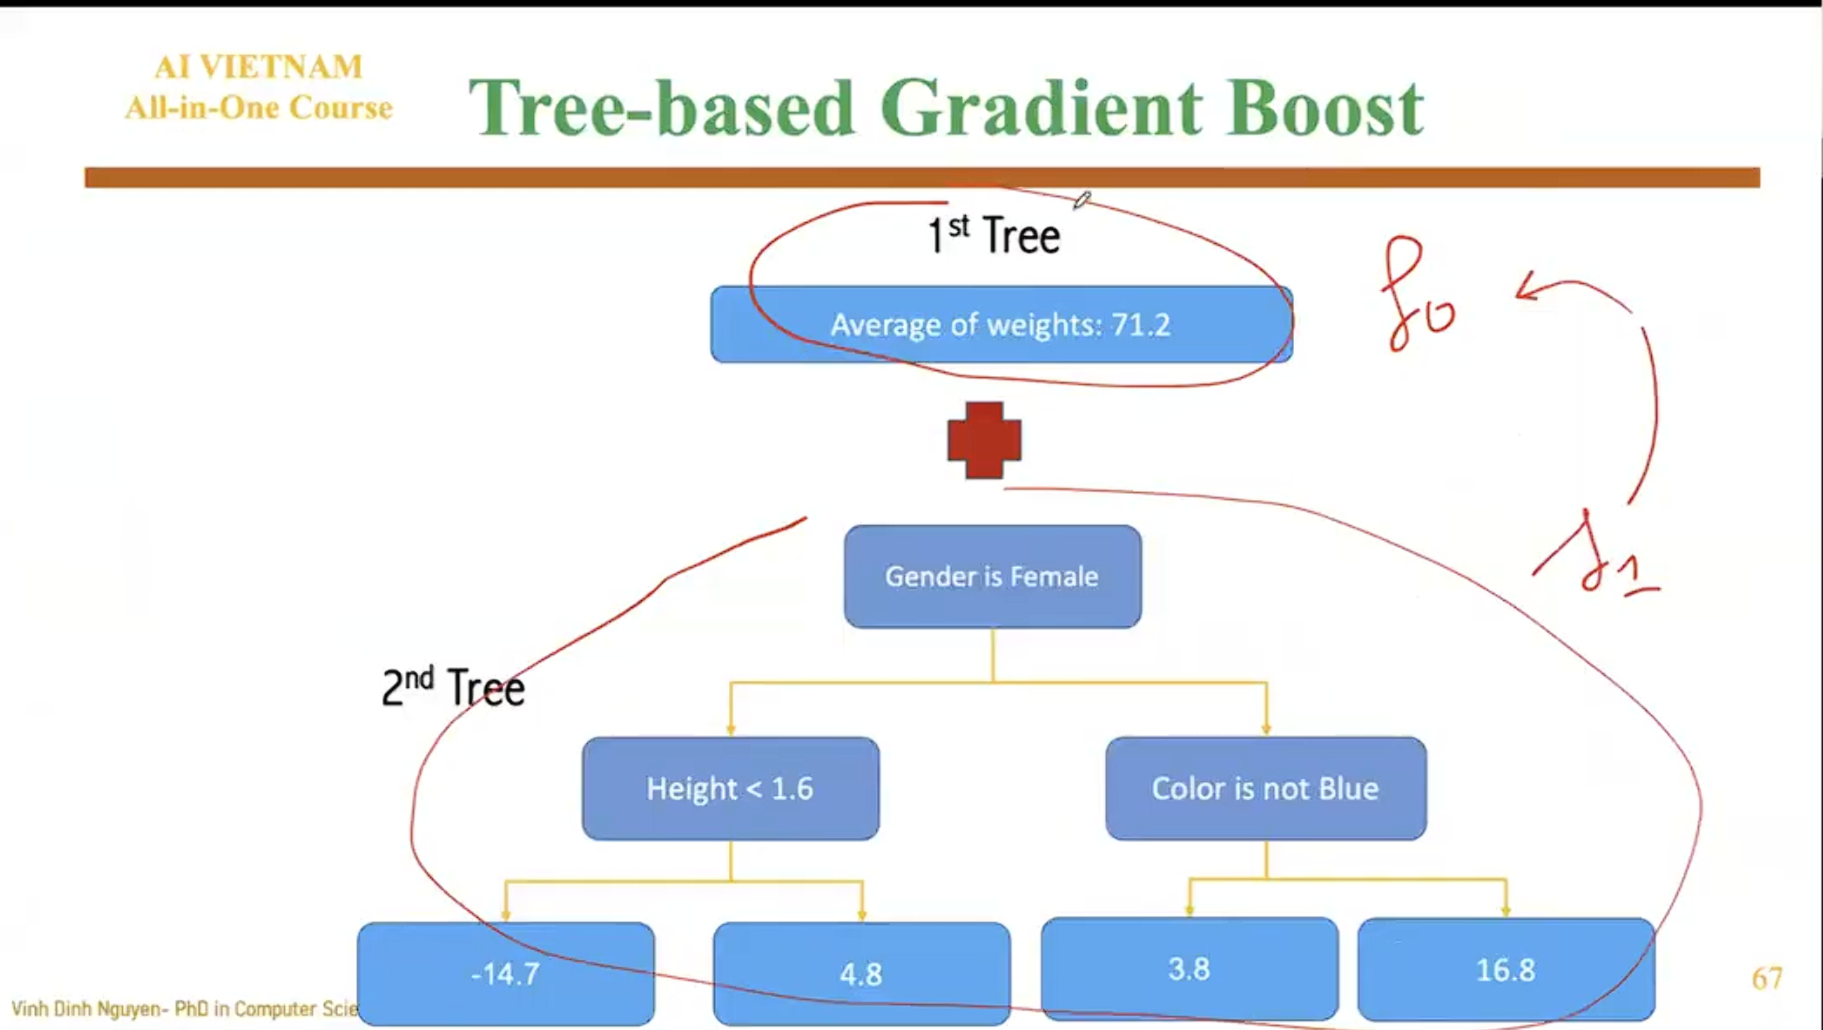

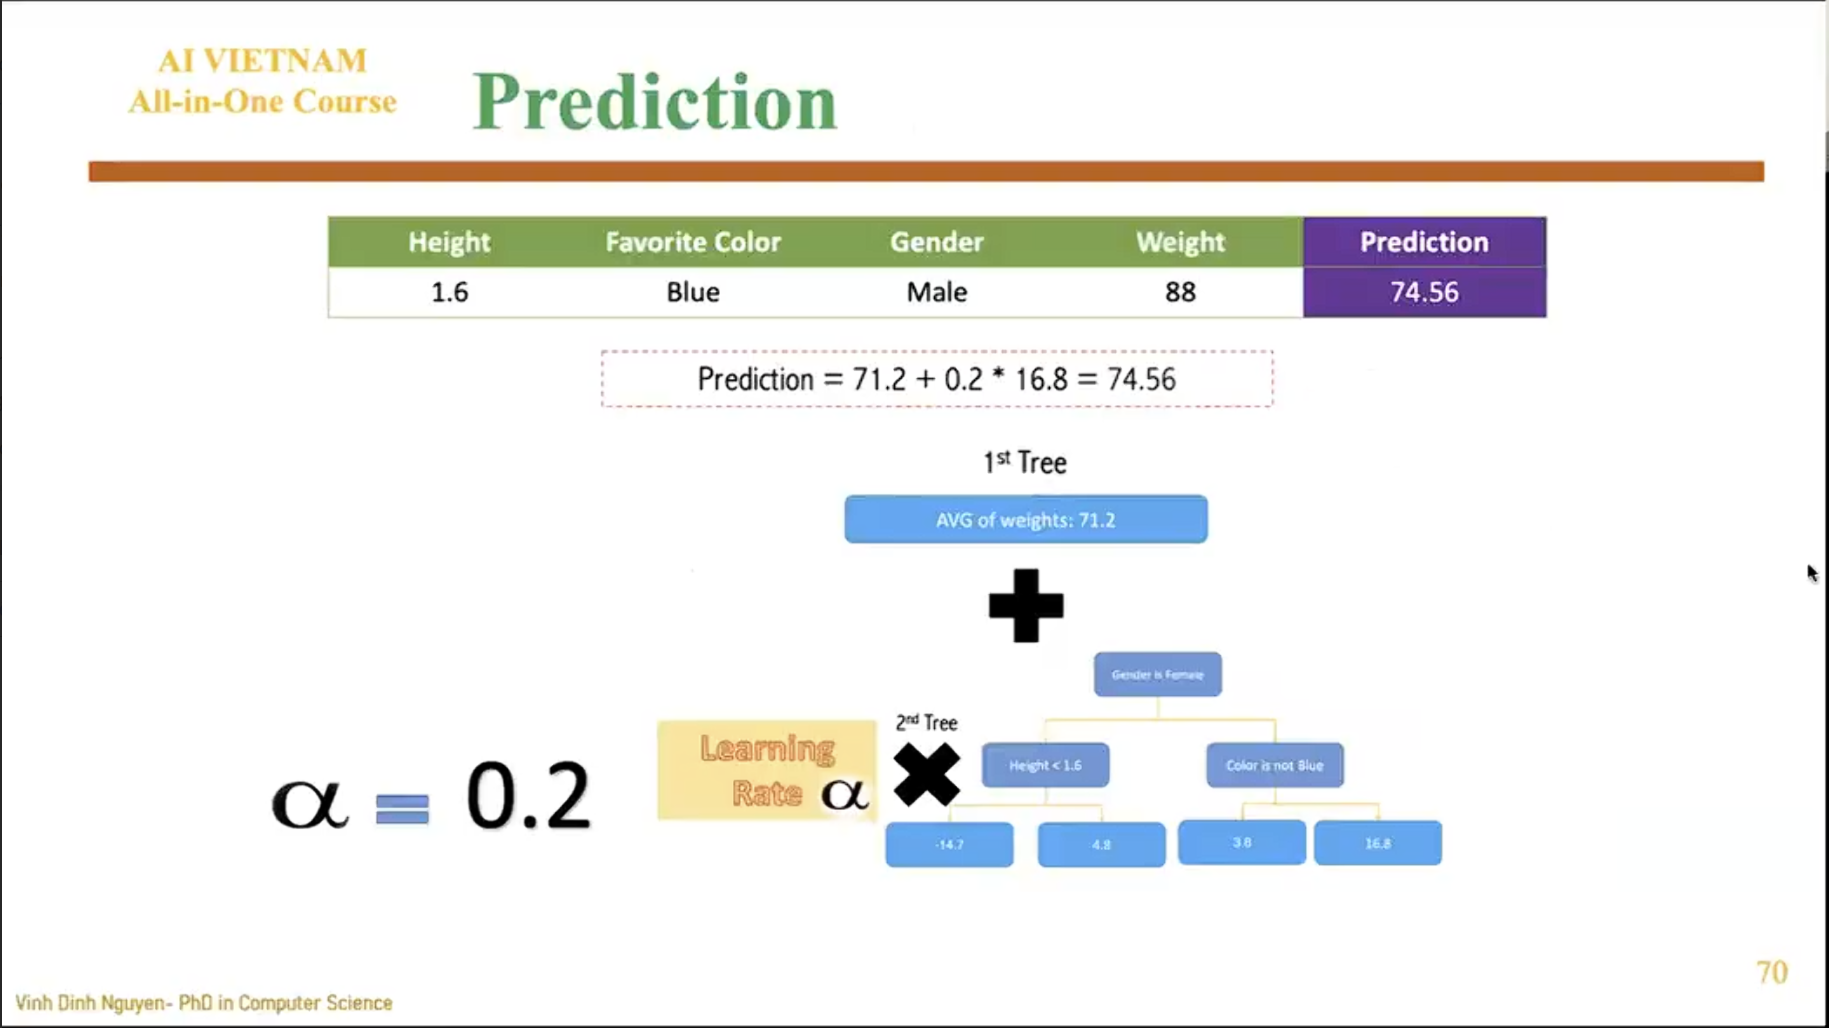

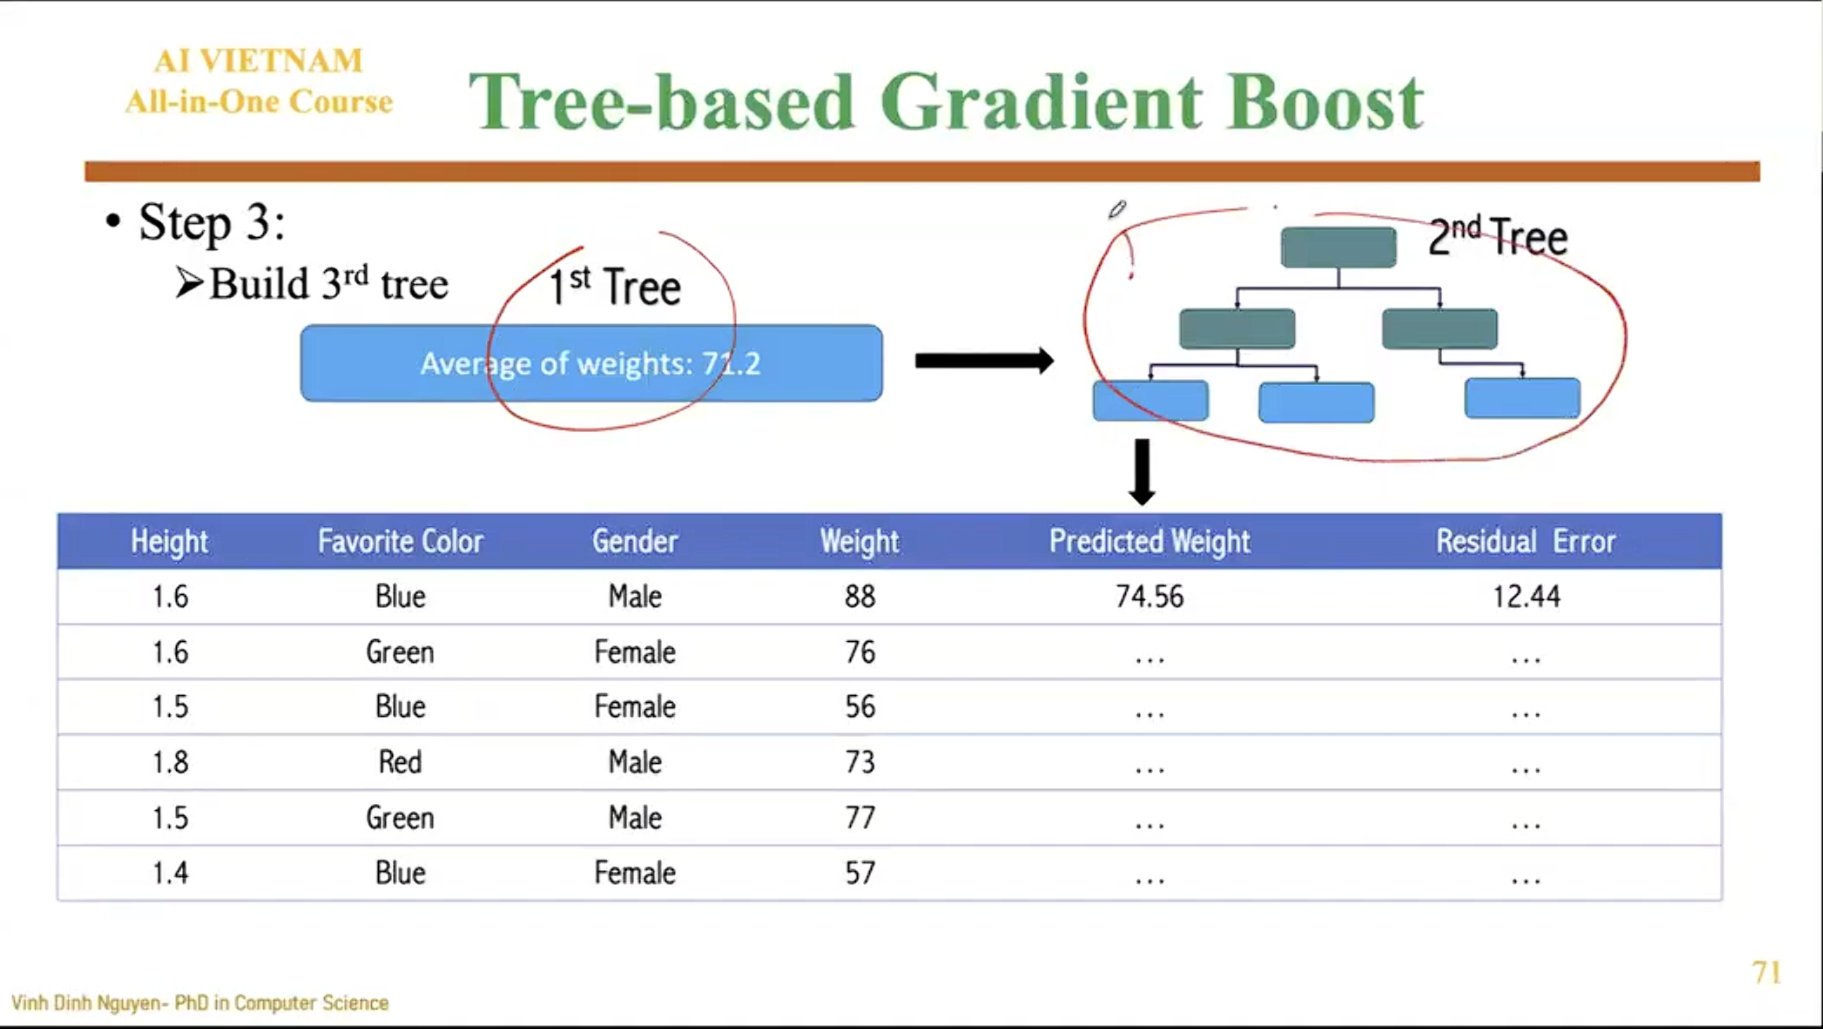



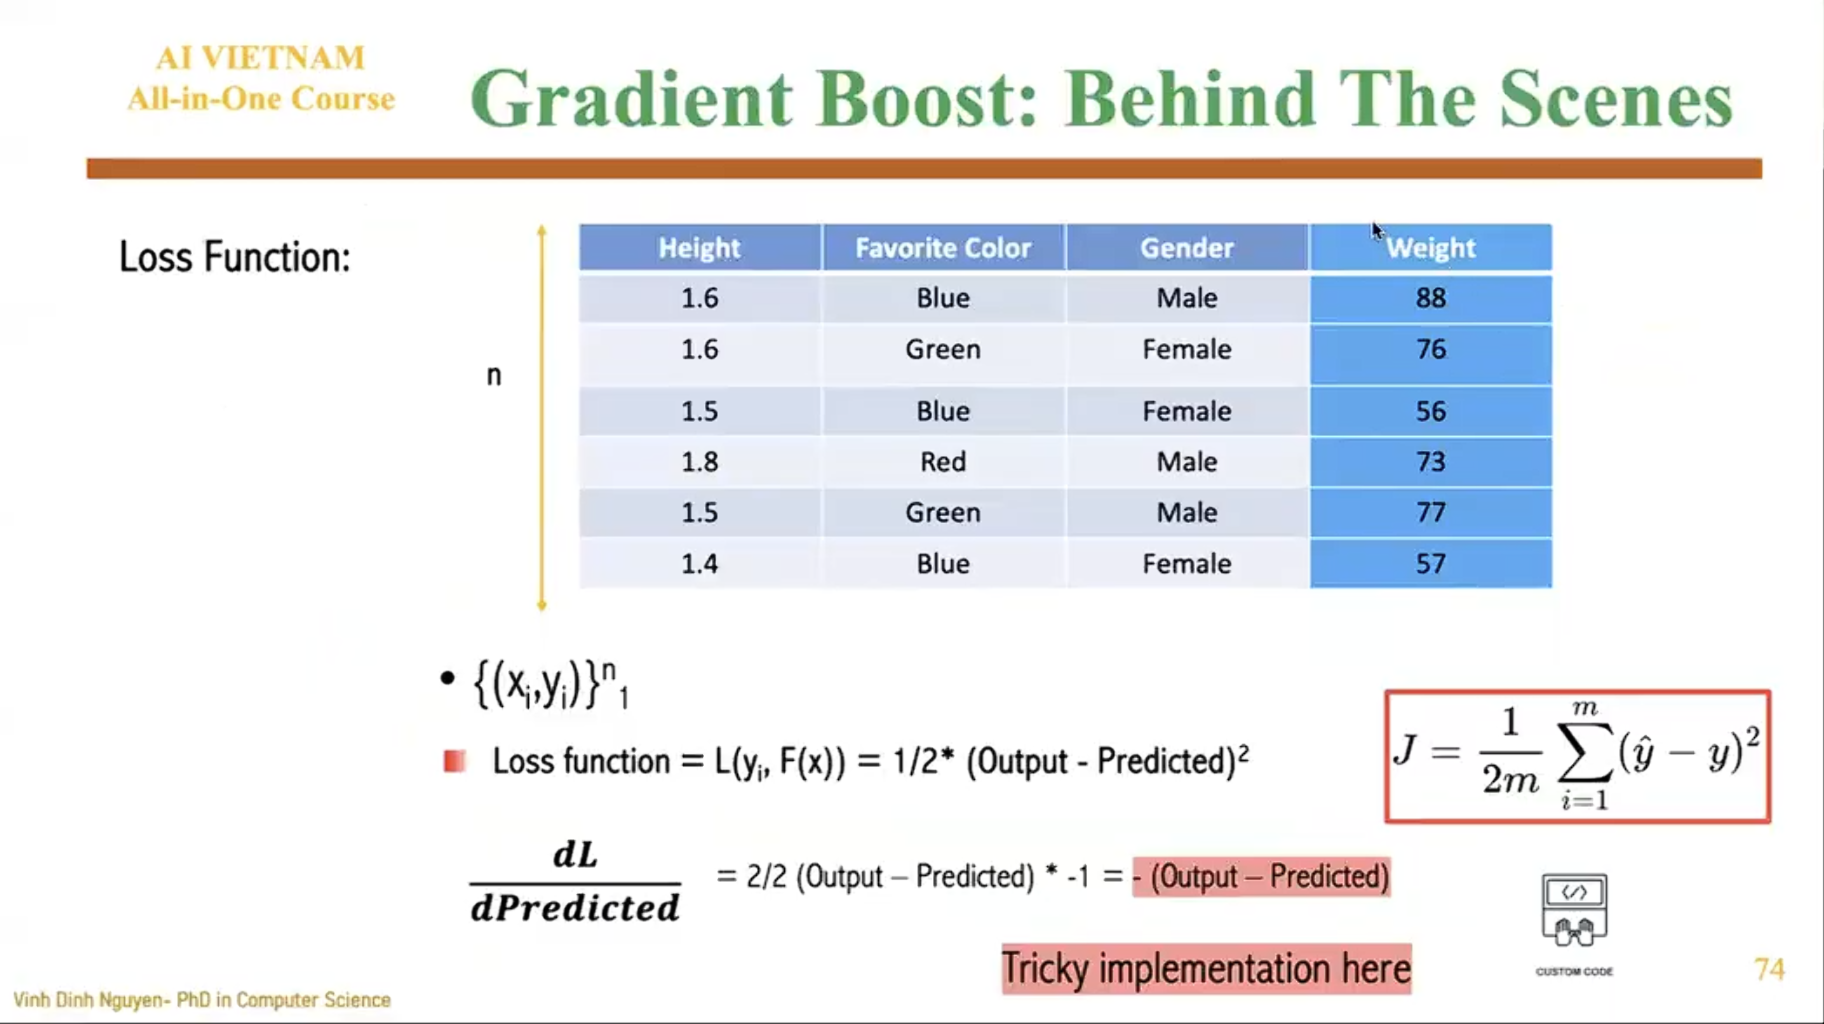

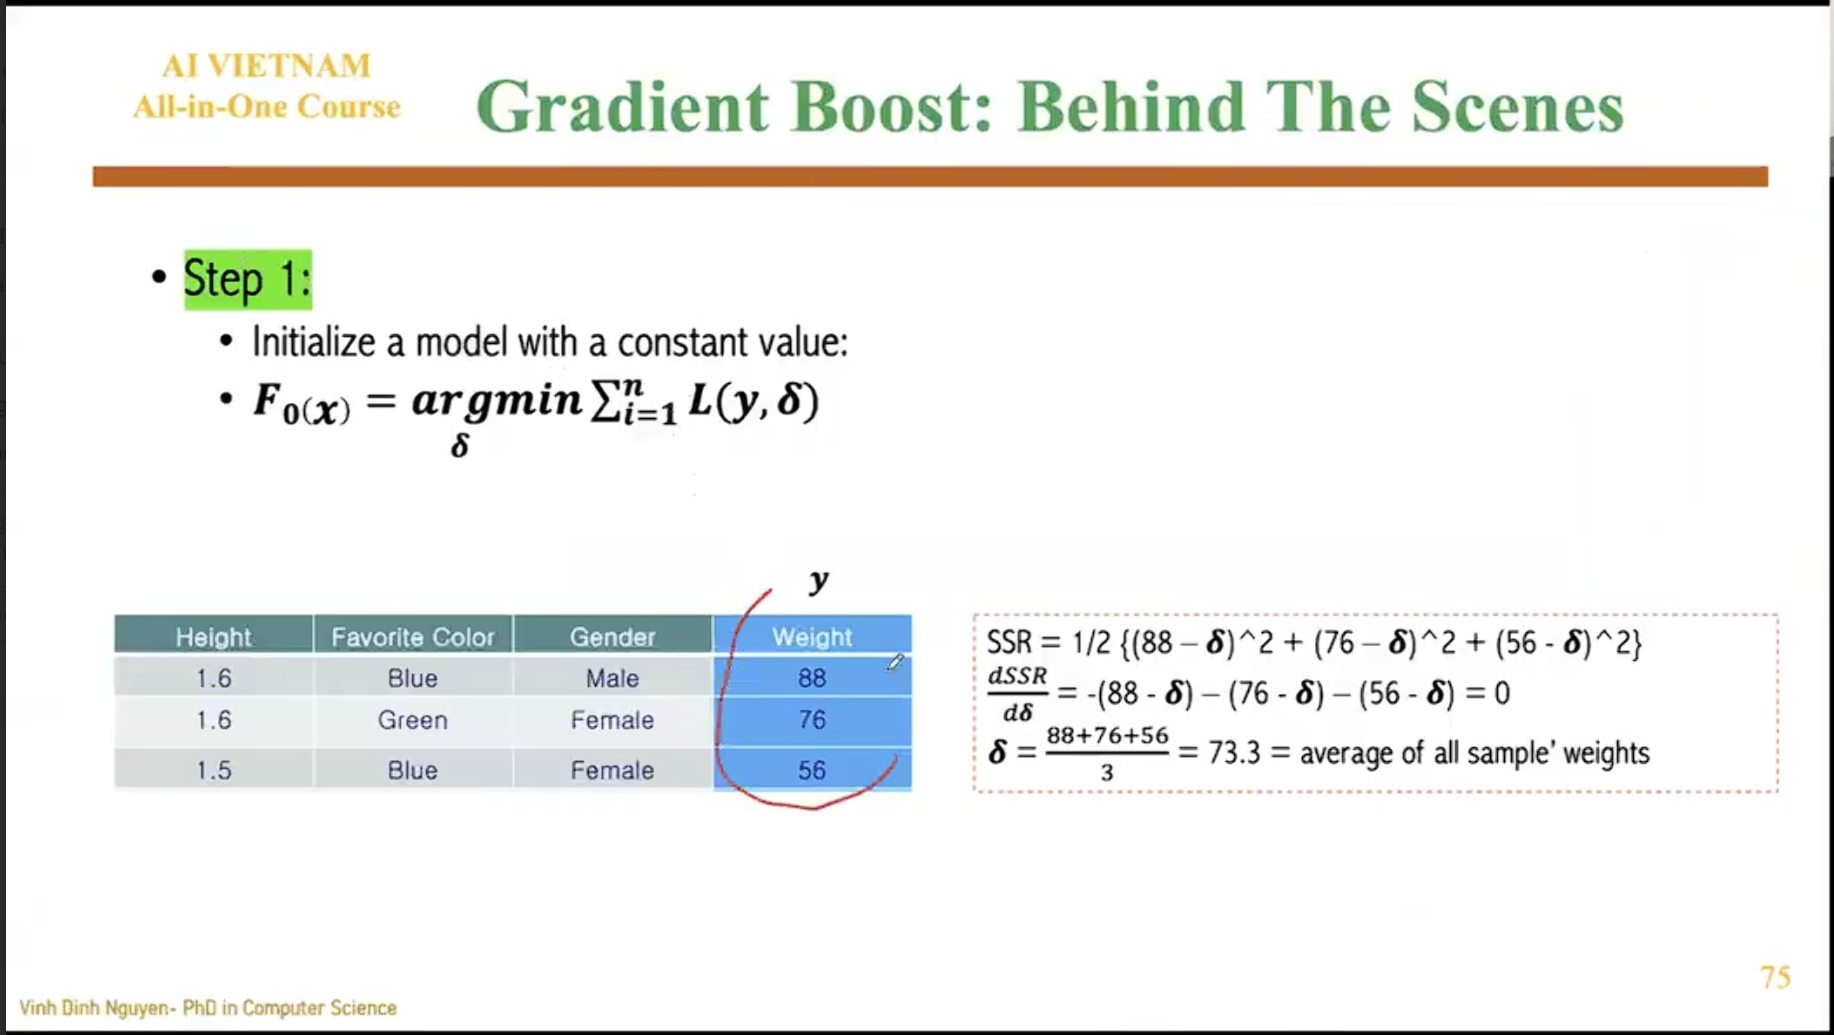

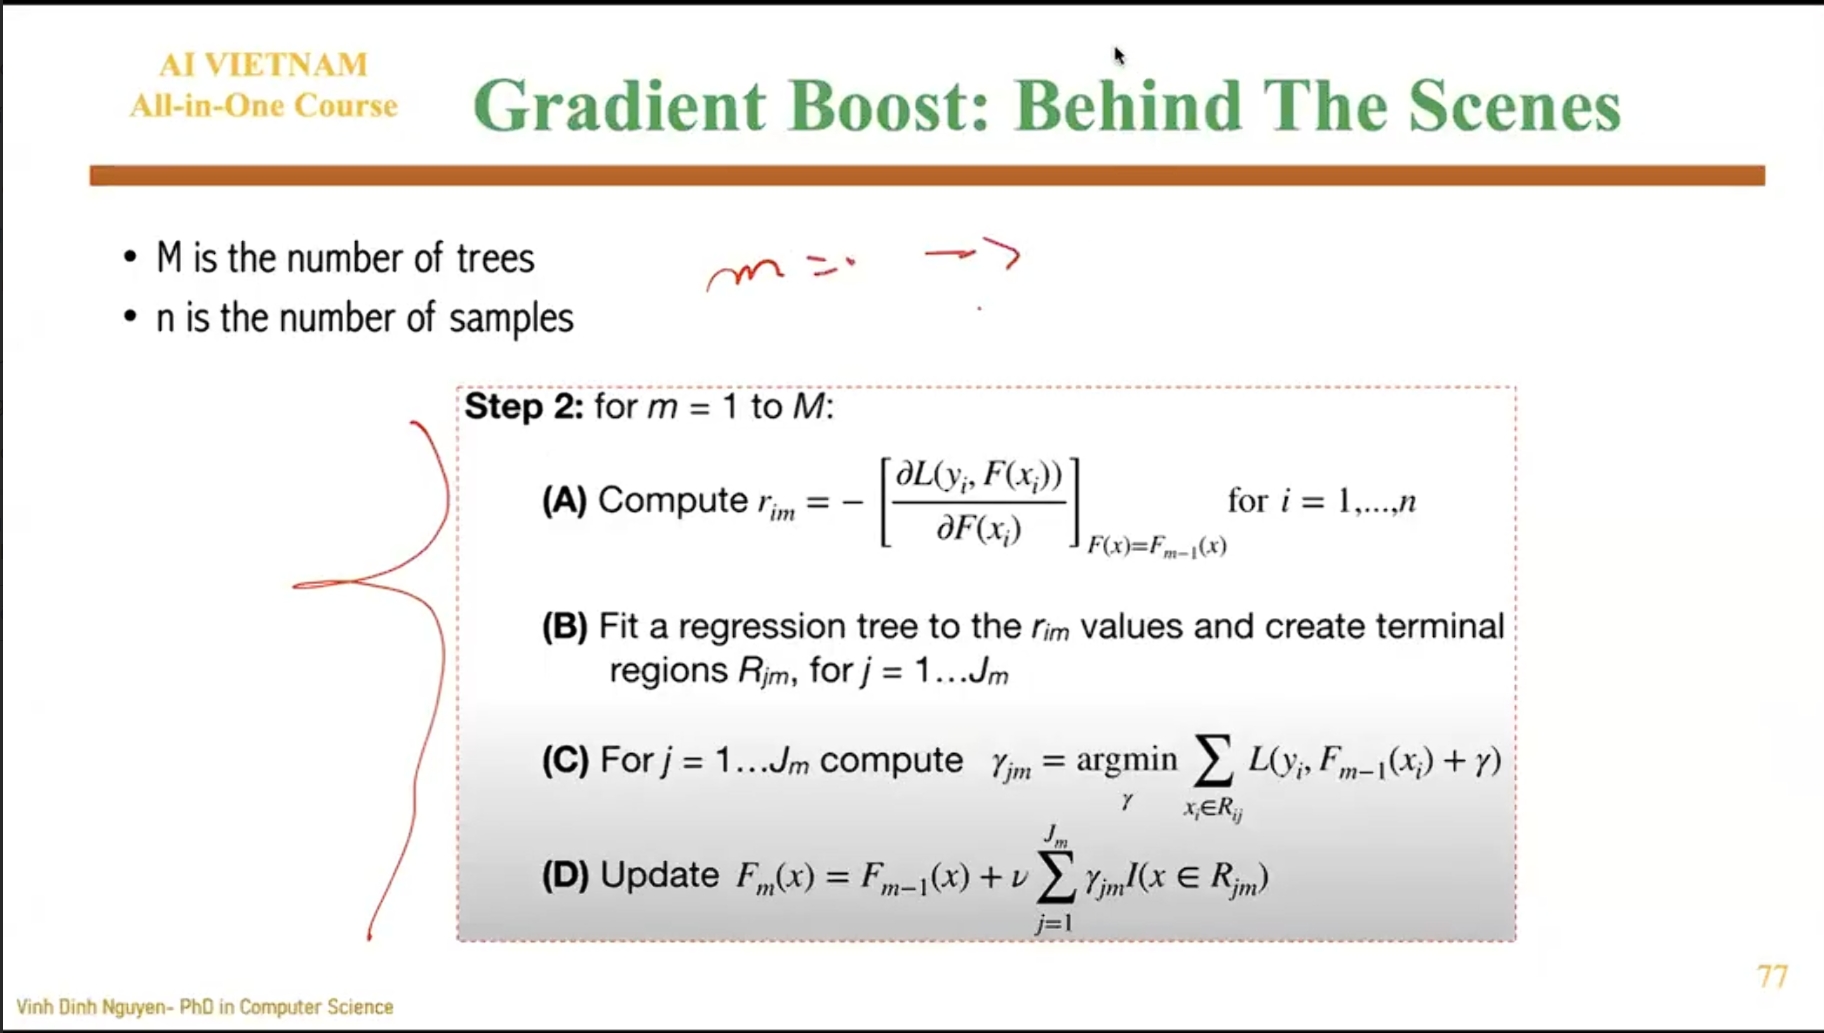

**1. Lý thuyết cốt lõi (Tư duy toán học)**

- Mô hình cộng (Additive Model): Chúng ta không tìm một hàm $F(x)$ hoàn hảo ngay lập tức. Chúng ta xây dựng nó từng bước:
$$F_{m}(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$
- Trong đó:
    - $F_{m-1}(x)$: Dự đoán của mô hình ở bước trước.
    - $h_m(x)$: "Weak learner" mới (thường là một cây quyết định nhỏ).
    - $\eta$: Learning rate (tốc độ học).

- Gradient Descent trong không gian hàm:
    - Thay vì tối ưu tham số $w$ như trong Linear Regression, chúng ta tối ưu chính giá trị dự đoán $F(x)$.
    - Mỗi "Weak learner" $h_m(x)$ sẽ học cách dự đoán Negative Gradient (đạo hàm âm) của hàm mất mát (Loss Function) đối với dự đoán hiện tại.
    - Nôm na: Mô hình sau sửa sai cho mô hình trước.    

In [1]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.base import BaseEstimator, RegressorMixin, ClassifierMixin

class GradientBoosting:
    def __init__(self, n_estimators = 100, learning_rate=0.1, max_depth=3, task='regression'):
        """
        Tham số:
        - n_estimators: Số lượng cây (vòng lặp boosting).
        - learning_rate: Tốc độ học (eta), giúp tránh overfitting.
        - max_depth: Độ sâu tối đa của mỗi cây (thường nhỏ, khoảng 3-5).
        - task: 'regression' (hồi quy) hoặc 'classification' (phân loại).
        """
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth  
        self.task = task
        self.trees=[]
        self.initial_prediction = None
    
    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    def _loss_gradient(self, y, y_pred):
        """
        Tính Negative Gradient (Pseudo-residuals).
        Đây là phần quan trọng nhất: Đạo hàm của Loss Function.
        """
        if self.task == 'regression':
            # Loss = 0.5 * (y - pred)^2  (MSE)
            # Gradient = -(y - pred)
            # Negative Gradient = y - pred
            return y - y_pred
        elif self.task == 'classification':
            # Loss = Log Loss (Binary Cross Entropy)
            # Negative Gradient = y - p (với p là xác suất dự đoán)
            # Lưu ý: y_pred ở đây đang ở dạng log-odds
            p = self._sigmoid(y_pred)
            return y - p
        
    def fit(self, X, y):
        """Huấn luyện mô hình"""
        # 1. Khởi tạo mô hình cơ sở F0
        if self.task == 'regression':
            self.initial_prediction = np.mean(y)
        else:
            # Với phân loại, khởi tạo bằng log-odds của xác suất
            prob = np.mean(y)
            prob = np.clip(prob, 1e-15, 1 - 1e-15)
            self.initial_prediction = np.log(prob / (1 - prob))

        # Tạo dự đoán ban đầu cho tất cả sample
        current_pred = np.full(y.shape, self.initial_prediction)

        # 2. Vòng lặp Boosting
        for i in range(self.n_estimators):
            # Bước A: Tính residuals dựa trên gradient
            residuals = self._loss_gradient(y, current_pred)

            # Bước B: Huấn luyện một cây mới để dự đoán residuals này
            tree = DecisionTreeRegressor(max_depth=self.max_depth, random_state=42)
            tree.fit(X, residuals)

            # Bước C: Cập nhật dự đoán hiện tại
            # F_moi = F_cu + learning_rate * du_doan_cua_cay
            update = tree.predict(X)
            current_pred += self.learning_rate * update

            # Lưu cây lại để dùng khi predict
            self.trees.append(tree)

            # In loss sau mỗi 10 vòng
            if i % 10 == 0:
                if self.task == 'regression':
                    loss = np.mean((y - current_pred)**2)
                else:
                    p = self._sigmoid(current_pred)
                    epsilon = 1e-15
                    loss = -np.mean(y * np.log(p+epsilon) + (1-y) * np.log(1-p+epsilon))
                print(f"Tree {i}: Loss = {loss:.4f}")

    
    def predict(self, X):
        """Dự đoán trên dữ liệu mới"""
        # Bắt đầu với giá trị khởi tạo F0
        pred = np.full(X.shape[0], self.initial_prediction)

        # Cộng dồn kết quả từ tất cả các cây
        for tree in self.trees:
            pred += self.learning_rate * tree.predict(X)

        # Trả về kết quả tùy theo bài toán
        if self.task == 'regression':
            return pred
        else:
            # Với phân loại, chuyển log-odds thành xác suất hoặc nhãn (0/1)
            # Ở đây trả về xác suất
            return self._sigmoid(pred)

**Giải thích chi tiết hoạt động**

A. Khởi tạo (__init__) và fit - Bước 1: $F_0$
- Gradient Boosting không bắt đầu từ số 0. Nó bắt đầu từ một "dự đoán ngây thơ".
    - Regression: Dự đoán ngây thơ nhất là trung bình cộng của tất cả giá trị $y$.- Classification: Chúng ta làm việc trên không gian log-odds (vì cây hồi quy trả về số thực, không phải xác suất [0,1]). Giá trị khởi tạo là log-odds của tỷ lệ class 1.

B. _loss_gradient - Trái tim của thuật toán

- Tại sao chúng ta lại fit cây vào y - y_pred?
    - Đây chính là Negative Gradient (hướng giảm lỗi nhanh nhất).
    - Nếu $Loss = \frac{1}{2}(y - F(x))^2$ (MSE), đạo hàm theo $F(x)$ là $-(y-F(x))$. Vậy để giảm lỗi, ta phải di chuyển về phía dương của $(y-F(x))$, tức là phần dư (residual).
    - Nếu mô hình đang dự đoán thấp hơn thực tế, residual dương $\rightarrow$ cây mới sẽ học số dương để bù vào.

C. Vòng lặp Boosting

tree.fit(X, residuals)
current_pred += self.learning_rate * update

- Chúng ta không fit cây vào $y$ (nhãn gốc). Chúng ta fit cây vào lỗi của mô hình hiện tại.
- learning_rate (ví dụ 0.1): Chúng ta không tin hoàn toàn vào cây mới này. Chúng ta chỉ lấy 10% kết quả của nó thôi. Điều này giúp mô hình không bị nhảy lung tung (giảm variance) và hội tụ mượt mà hơn.

# Regression

Tree 0: Loss = 5660.7051
Tree 10: Loss = 1094.7487
Tree 20: Loss = 340.3106
Tree 30: Loss = 196.3750
Tree 40: Loss = 165.5117
Tree 50: Loss = 155.9160
Tree 60: Loss = 150.5657
Tree 70: Loss = 145.5745
Tree 80: Loss = 141.0977
Tree 90: Loss = 136.2011
Regression MSE: 131.89


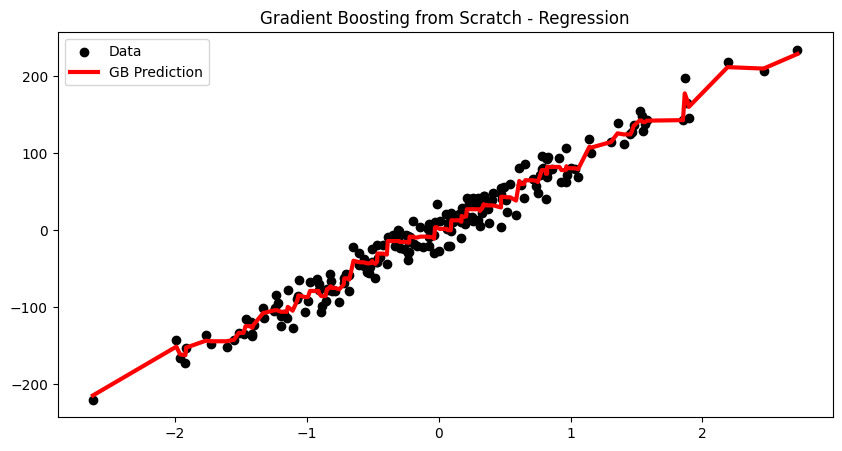

In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error

# 1. Tạo dữ liệu
X, y = make_regression(n_samples=200, n_features=1, noise=15, random_state=42)

# 2. Huấn luyện
gb_reg = GradientBoosting(n_estimators=100, learning_rate=0.1, max_depth=2, task='regression')
gb_reg.fit(X, y)

# 3. Dự đoán
y_pred = gb_reg.predict(X)

# 4. Đánh giá và Vẽ biểu đồ
mse = mean_squared_error(y, y_pred)
print(f"Regression MSE: {mse:.2f}")

plt.figure(figsize=(10, 5))
plt.scatter(X, y, color='black', label='Data')
# Sort X để vẽ line cho đẹp
sort_idx = X.flatten().argsort()
plt.plot(X[sort_idx], y_pred[sort_idx], color='red', linewidth=3, label='GB Prediction')
plt.title("Gradient Boosting from Scratch - Regression")
plt.legend()
plt.show()

# Classification    

In [4]:
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score

# 1. Tạo dữ liệu
X_clf, y_clf = make_classification(n_samples=200, n_features=4, random_state=42)

# 2. Huấn luyện
gb_clf = GradientBoosting(n_estimators=100, learning_rate=0.1, max_depth=3, task='classification')
gb_clf.fit(X_clf, y_clf)

# 3. Dự đoán (Xác suất -> Nhãn 0/1)
y_prob = gb_clf.predict(X_clf)
y_pred_class = (y_prob > 0.5).astype(int)

# 4. Đánh giá
acc = accuracy_score(y_clf, y_pred_class)
print(f"Classification Accuracy: {acc:.2f}")

Tree 0: Loss = 0.6749
Tree 10: Loss = 0.5349
Tree 20: Loss = 0.4478
Tree 30: Loss = 0.3907
Tree 40: Loss = 0.3499
Tree 50: Loss = 0.3194
Tree 60: Loss = 0.2947
Tree 70: Loss = 0.2758
Tree 80: Loss = 0.2606
Tree 90: Loss = 0.2473
Classification Accuracy: 0.94
